In [2]:
# ============================================================
# 1. Configuração do notebook de análise
# ============================================================

from pathlib import Path

import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("ANÁLISE DOS ÍNDICES DE VEGETAÇÃO — 2025")
print("=" * 70)

print("\n✓ Bibliotecas carregadas")
print("✓ Ambiente de análise configurado")

ANÁLISE DOS ÍNDICES DE VEGETAÇÃO — 2025

✓ Bibliotecas carregadas
✓ Ambiente de análise configurado


In [3]:
# ============================================================
# 2. Carregamento das composições dos índices
# ============================================================

pasta_indices = (
    Path(
        r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao"
    )
    / "data"
    / "processed"
    / "indices"
)

arquivos_indices = {
    "NDVI": pasta_indices / "ndvi" / "ndvi_mediana_2025.tif",
    "EVI": pasta_indices / "evi" / "evi_mediana_2025.tif",
    "NDMI": pasta_indices / "ndmi" / "ndmi_mediana_2025.tif"
}

print("=" * 70)
print("COMPOSIÇÕES DOS ÍNDICES")
print("=" * 70)

for nome, arquivo in arquivos_indices.items():

    if arquivo.exists():

        with rasterio.open(arquivo) as src:

            dados = src.read(1)

            print(f"\n✓ {nome}")
            print(f"  Arquivo: {arquivo.name}")
            print(f"  CRS: {src.crs}")
            print(
                f"  Dimensões: "
                f"{src.height} x {src.width}"
            )
            print(
                f"  Resolução: "
                f"{src.res[0]:.2f} x "
                f"{src.res[1]:.2f} m"
            )

    else:

        print(
            f"\n⚠️ {nome} — arquivo não encontrado:"
        )
        print(f"  {arquivo}")

print("\n" + "=" * 70)
print("✓ VERIFICAÇÃO DOS ÍNDICES CONCLUÍDA")
print("=" * 70)

COMPOSIÇÕES DOS ÍNDICES

✓ NDVI
  Arquivo: ndvi_mediana_2025.tif
  CRS: EPSG:32722
  Dimensões: 222 x 140
  Resolução: 10.00 x 10.00 m

✓ EVI
  Arquivo: evi_mediana_2025.tif
  CRS: EPSG:32722
  Dimensões: 222 x 140
  Resolução: 10.00 x 10.00 m

✓ NDMI
  Arquivo: ndmi_mediana_2025.tif
  CRS: EPSG:32722
  Dimensões: 112 x 71
  Resolução: 20.00 x 20.00 m

✓ VERIFICAÇÃO DOS ÍNDICES CONCLUÍDA


In [4]:
# ============================================================
# 3. Área de estudo — propriedade
# ============================================================

pasta_raw = (
    Path(
        r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao"
    )
    / "data"
    / "raw"
)

arquivo_imovel = (
    pasta_raw / "Area_do_Imovel.zip"
)

imovel = gpd.read_file(
    arquivo_imovel
)

# CRS dos índices
crs_indices = "EPSG:32722"

# Reprojeção da propriedade
imovel = imovel.to_crs(
    crs_indices
)

print("=" * 70)
print("ÁREA DE ESTUDO")
print("=" * 70)

print(f"\n✓ Arquivo: {arquivo_imovel.name}")
print(f"✓ Feições: {len(imovel)}")
print(f"✓ CRS: {imovel.crs}")

print(
    f"✓ Área aproximada: "
    f"{imovel.geometry.iloc[0].area / 10000:.2f} ha"
)

print("\n" + "=" * 70)
print("✓ ÁREA DE ESTUDO CARREGADA")
print("=" * 70)

ÁREA DE ESTUDO

✓ Arquivo: Area_do_Imovel.zip
✓ Feições: 2
✓ CRS: EPSG:32722
✓ Área aproximada: 189.19 ha

✓ ÁREA DE ESTUDO CARREGADA


In [5]:
# ============================================================
# 4. Camadas de caracterização da propriedade
# ============================================================

arquivos_caracterizacao = {
    "Cobertura do Solo": (
        pasta_raw / "Cobertura_do_Solo.zip"
    ),
    "APP": (
        pasta_raw / "Area_de_Preservacao_Permanente.zip"
    ),
    "Reserva Legal": (
        pasta_raw / "Reserva_Legal.zip"
    )
}

camadas_caracterizacao = {}

print("=" * 70)
print("CAMADAS DE CARACTERIZAÇÃO")
print("=" * 70)

for nome, arquivo in arquivos_caracterizacao.items():

    camada = gpd.read_file(
        arquivo
    )

    camada = camada.to_crs(
        crs_indices
    )

    camadas_caracterizacao[nome] = camada

    print(
        f"\n✓ {nome}"
    )

    print(
        f"  Feições: {len(camada)}"
    )

    print(
        f"  CRS: {camada.crs}"
    )

print("\n" + "=" * 70)
print("✓ CAMADAS DE CARACTERIZAÇÃO CARREGADAS")
print("=" * 70)

CAMADAS DE CARACTERIZAÇÃO

✓ Cobertura do Solo
  Feições: 2
  CRS: EPSG:32722

✓ APP
  Feições: 10
  CRS: EPSG:32722

✓ Reserva Legal
  Feições: 2
  CRS: EPSG:32722

✓ CAMADAS DE CARACTERIZAÇÃO CARREGADAS


In [6]:
# ============================================================
# 5. Classes de cobertura do solo
# ============================================================

cobertura = camadas_caracterizacao[
    "Cobertura do Solo"
]

print("=" * 70)
print("COBERTURA DO SOLO")
print("=" * 70)

print("\n✓ Campos disponíveis:")

for campo in cobertura.columns:
    print(f"  - {campo}")

print("\n" + "=" * 70)
print("✓ VALORES DOS ATRIBUTOS")
print("=" * 70)

display(
    cobertura
)

COBERTURA DO SOLO

✓ Campos disponíveis:
  - recibo
  - area
  - tema
  - geometry

✓ VALORES DOS ATRIBUTOS


,recibo,area,tema,geometry
0,SP-3552205-CBC00ACCA5874AC3B43BF5DF37F26251,169.7244,Ãrea Consolidada,"MULTIPOLYGON (((853998.164 7400586.174, 853997..."
1,SP-3552205-CBC00ACCA5874AC3B43BF5DF37F26251,18.9554,Remanescente de VegetaÃ§Ã£o Nativa,"MULTIPOLYGON (((854028.332 7400604.76, 854029...."


ESTATÍSTICAS DA PROPRIEDADE
Área total (perímetro):       378.38 ha
Área consolidada:             169.97 ha (44.9%)
Remanescente nativo:           18.98 ha (5.0%)
APP:                           50.99 ha (13.5%)
Reserva Legal:                 37.96 ha (10.0%)
Área de Uso Restrito:         183.43 ha (48.5%)
Marcadores APP:             1 ponto(s)


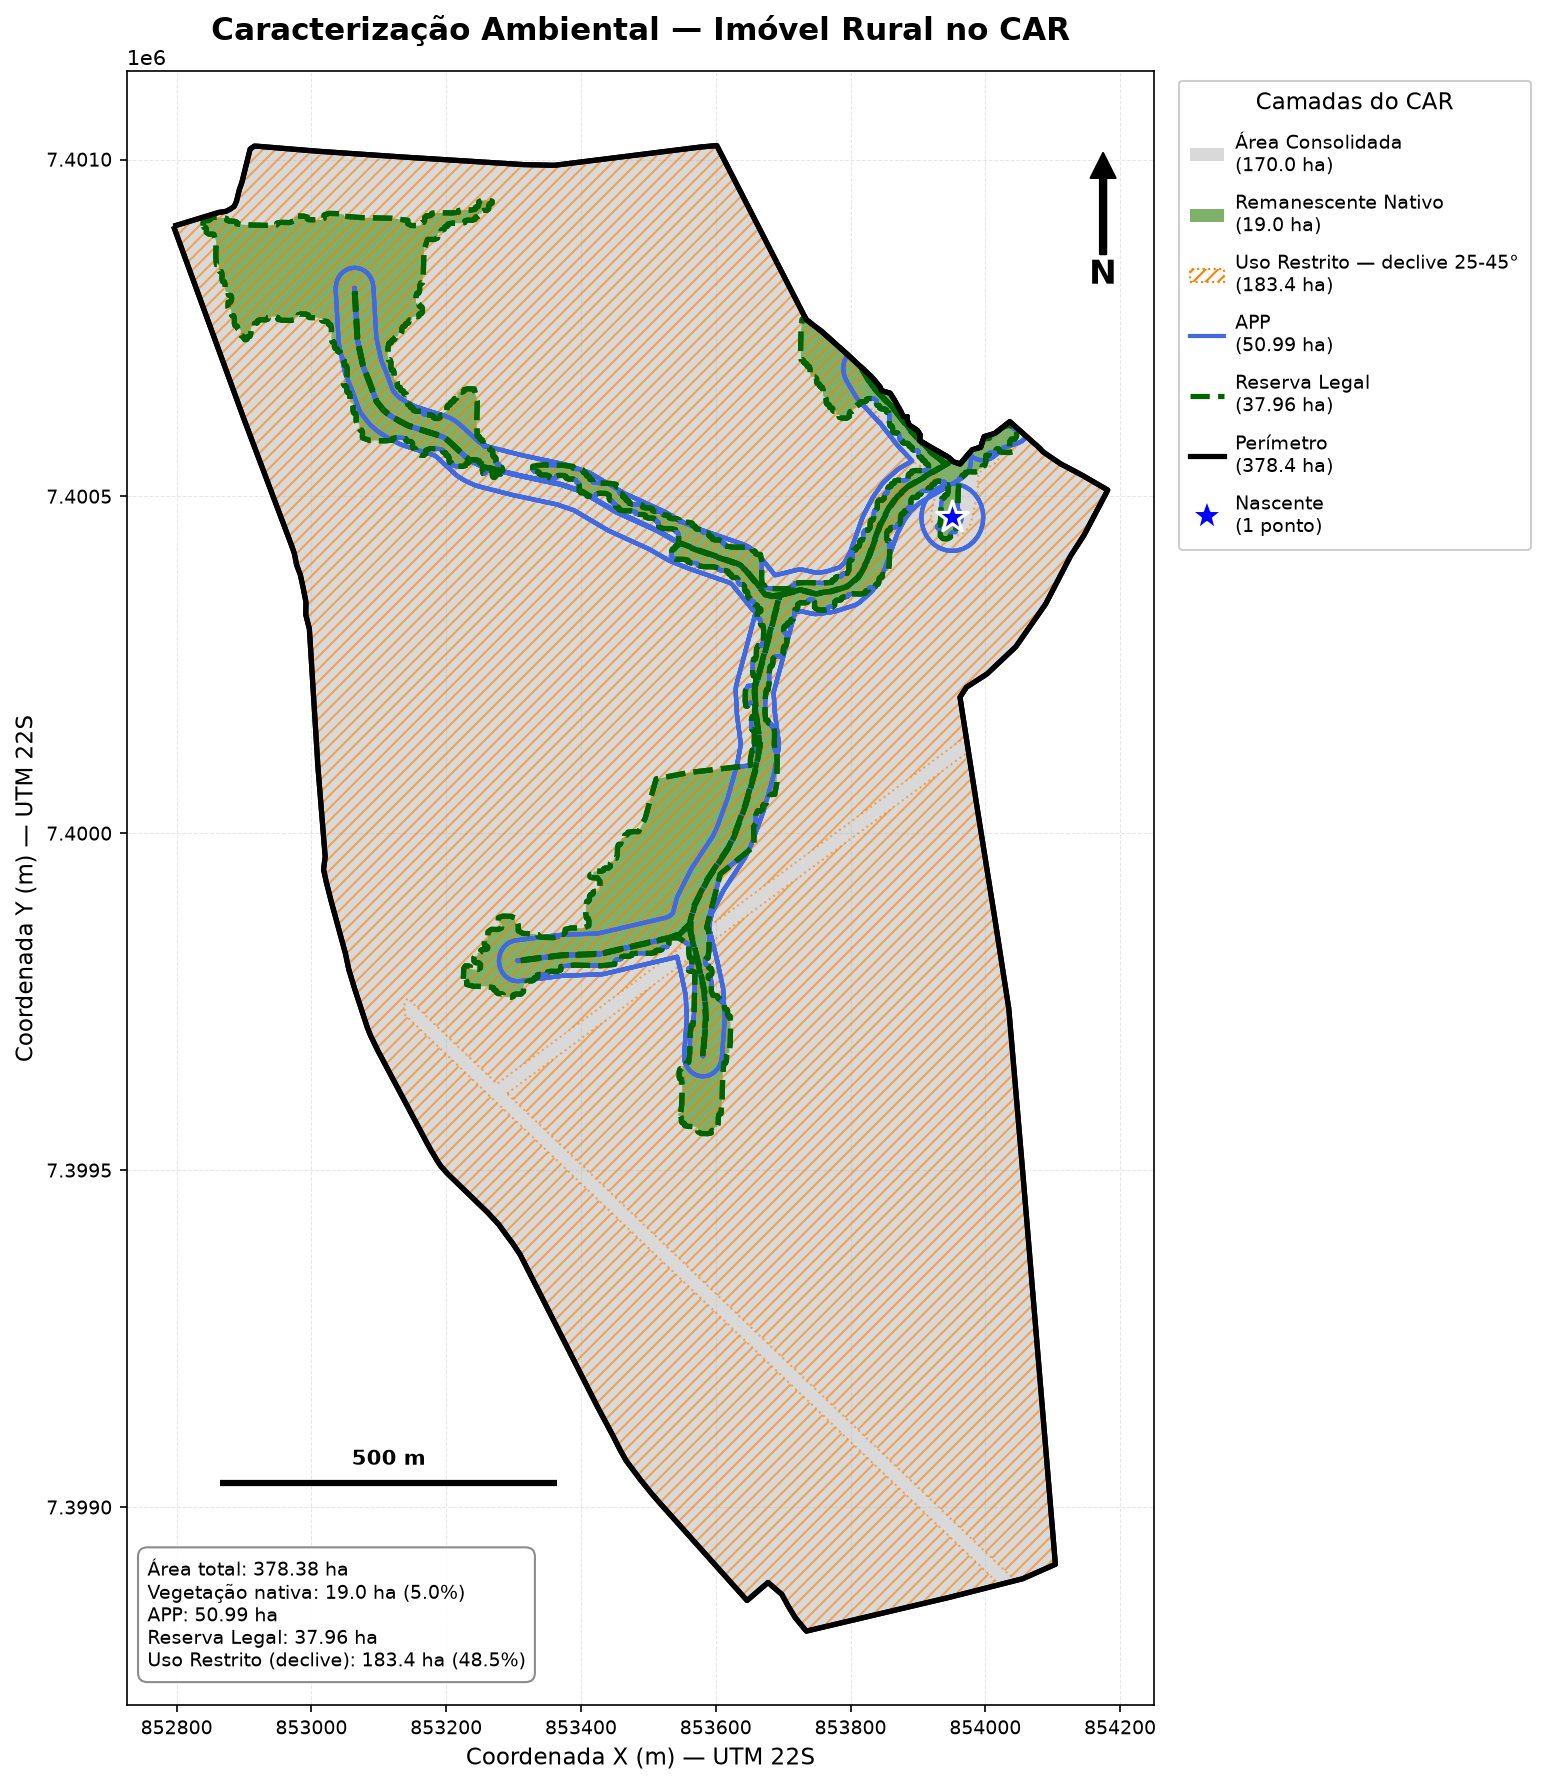


✓ Mapa de caracterização profissional gerado


In [24]:
# ============================================================
# MAPA DE CARACTERIZAÇÃO AMBIENTAL 
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path
import numpy as np

# ------------------------------------------------------------
# Caminhos
# ------------------------------------------------------------
BASE = Path(r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao")
CAR_DIR = BASE / "data" / "raw"

# ------------------------------------------------------------
# Carregar TODAS as camadas do CAR
# ------------------------------------------------------------
cob = gpd.read_file(CAR_DIR / "Cobertura_do_Solo" / "Cobertura_do_Solo.shp").to_crs("EPSG:32722")
app = gpd.read_file(CAR_DIR / "Area_de_Preservacao_Permanente" / "Area_de_Preservacao_Permanente.shp").to_crs("EPSG:32722")
rl  = gpd.read_file(CAR_DIR / "Reserva_Legal" / "Reserva_Legal.shp").to_crs("EPSG:32722")
aur = gpd.read_file(CAR_DIR / "Area_de_Uso_Restrito" / "Area_de_Uso_Restrito.shp").to_crs("EPSG:32722")
marc = gpd.read_file(CAR_DIR / "MARCADORES_Area_de_Preservacao_Permanente" / "MARCADORES_Area_de_Preservacao_Permanente.shp").to_crs("EPSG:32722")
perim = gpd.read_file(CAR_DIR / "Area_do_Imovel" / "Area_do_Imovel.shp").to_crs("EPSG:32722")

# ------------------------------------------------------------
# Estatísticas — calcular áreas
# ------------------------------------------------------------
area_perim = perim.geometry.area.sum() / 10000
area_app = app.geometry.area.sum() / 10000
area_rl = rl.geometry.area.sum() / 10000
area_aur = aur.geometry.area.sum() / 10000

# Cobertura do solo — separar classes
cob_consolidada = cob[cob["tema"].str.contains("Consolidada", na=False)]
cob_nativa = cob[cob["tema"].str.contains("Nativa", na=False)]

area_consolidada = cob_consolidada.geometry.area.sum() / 10000
area_nativa = cob_nativa.geometry.area.sum() / 10000

print("=" * 70)
print("ESTATÍSTICAS DA PROPRIEDADE")
print("=" * 70)
print(f"Área total (perímetro):     {area_perim:>8,.2f} ha")
print(f"Área consolidada:           {area_consolidada:>8,.2f} ha ({area_consolidada/area_perim*100:.1f}%)")
print(f"Remanescente nativo:        {area_nativa:>8,.2f} ha ({area_nativa/area_perim*100:.1f}%)")
print(f"APP:                        {area_app:>8,.2f} ha ({area_app/area_perim*100:.1f}%)")
print(f"Reserva Legal:              {area_rl:>8,.2f} ha ({area_rl/area_perim*100:.1f}%)")
print(f"Área de Uso Restrito:       {area_aur:>8,.2f} ha ({area_aur/area_perim*100:.1f}%)")
print(f"Marcadores APP:             {len(marc)} ponto(s)")

# ------------------------------------------------------------
# Figura (mais larga para caber a legenda fora do mapa)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 12), dpi=150)

# ------------------------------------------------------------
# 1. Cobertura do Solo (fundo)
# ------------------------------------------------------------
cob_consolidada.plot(
    ax=ax,
    color="#d9d9d9",
    edgecolor="none",
    zorder=1
)

cob_nativa.plot(
    ax=ax,
    color="#7fb069",
    edgecolor="none",
    zorder=2
)

# ------------------------------------------------------------
# 2. Área de Uso Restrito (hachura)
# ------------------------------------------------------------
aur.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#ff7f00",
    linewidth=1,
    linestyle=":",
    hatch="////",
    alpha=0.6,
    zorder=3
)

# ------------------------------------------------------------
# 3. APP (linha azul)
# ------------------------------------------------------------
app.plot(
    ax=ax,
    facecolor="none",
    edgecolor="royalblue",
    linewidth=2,
    zorder=4
)

# ------------------------------------------------------------
# 4. Reserva Legal (linha verde escura)
# ------------------------------------------------------------
rl.plot(
    ax=ax,
    facecolor="none",
    edgecolor="darkgreen",
    linewidth=2.5,
    linestyle="--",
    zorder=5
)

# ------------------------------------------------------------
# 5. Marcador de nascente (ponto)
# ------------------------------------------------------------
if len(marc) > 0:
    marc.plot(
        ax=ax,
        marker="*",
        color="blue",
        markersize=250,
        edgecolor="white",
        linewidth=1.5,
        zorder=7
    )

# ------------------------------------------------------------
# 6. Perímetro (linha preta grossa)
# ------------------------------------------------------------
perim.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.5,
    zorder=6
)

# ------------------------------------------------------------
# Elementos cartográficos
# ------------------------------------------------------------
xmin, ymin, xmax, ymax = perim.total_bounds
margem_x = (xmax - xmin) * 0.05
margem_y = (ymax - ymin) * 0.05
ax.set_xlim(xmin - margem_x, xmax + margem_x)
ax.set_ylim(ymin - margem_y, ymax + margem_y)

ax.set_xlabel("Coordenada X (m) — UTM 22S", fontsize=11)
ax.set_ylabel("Coordenada Y (m) — UTM 22S", fontsize=11)

# Norte
ax.annotate(
    "N",
    xy=(0.95, 0.95), xytext=(0.95, 0.87),
    xycoords="axes fraction", textcoords="axes fraction",
    arrowprops=dict(facecolor="black", width=3, headwidth=12),
    fontsize=16, ha="center", fontweight="bold"
)

# ------------------------------------------------------------
# Escala gráfica — MOVIDA MAIS PARA CIMA
# ------------------------------------------------------------
escala_m = 500
x0 = xmin + (xmax - xmin) * 0.05
y0 = ymin + (ymax - ymin) * 0.10   # ← Era 0.05, agora 0.20 (mais acima)

ax.plot(
    [x0, x0 + escala_m],
    [y0, y0],
    "k-",
    linewidth=3,
    solid_capstyle="butt"
)
ax.text(
    x0 + escala_m / 2,
    y0 + (ymax - ymin) * 0.012,
    f"{escala_m} m",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

# Grid
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3, zorder=0)

# ------------------------------------------------------------
# Legenda personalizada (SEM EMOJIS)
# ------------------------------------------------------------
legenda = [
    Patch(
        facecolor="#d9d9d9", edgecolor="none",
        label=f"Área Consolidada\n({area_consolidada:.1f} ha)"
    ),
    Patch(
        facecolor="#7fb069", edgecolor="none",
        label=f"Remanescente Nativo\n({area_nativa:.1f} ha)"
    ),
    Patch(
        facecolor="none", edgecolor="#ff7f00",
        linestyle=":", hatch="////",
        label=f"Uso Restrito — declive 25-45°\n({area_aur:.1f} ha)"
    ),
    Line2D(
        [0], [0], color="royalblue", linewidth=2,
        label=f"APP\n({area_app:.2f} ha)"
    ),
    Line2D(
        [0], [0], color="darkgreen", linewidth=2.5, linestyle="--",
        label=f"Reserva Legal\n({area_rl:.2f} ha)"
    ),
    Line2D(
        [0], [0], color="black", linewidth=2.5,
        label=f"Perímetro\n({area_perim:.1f} ha)"
    ),
]

if len(marc) > 0:
    legenda.append(
        Line2D(
            [0], [0], marker="*", color="blue", linestyle="none",
            markersize=15, markeredgecolor="white",
            label=f"Nascente\n({len(marc)} ponto)"
        )
    )

# Eixo separado para a legenda (fora do mapa)
divider = make_axes_locatable(ax)
leg_ax = divider.append_axes("right", size="22%", pad=0.1)
leg_ax.axis("off")

leg_ax.legend(
    handles=legenda,
    loc="upper left",
    frameon=True,
    framealpha=0.95,
    fontsize=9,
    title="Camadas do CAR",
    title_fontsize=11,
    borderpad=0.6,
    labelspacing=0.8,
    handlelength=1.8,
    handletextpad=0.6
)

# ------------------------------------------------------------
# Título e aparência
# ------------------------------------------------------------
ax.set_title(
    "Caracterização Ambiental — Imóvel Rural no CAR",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_aspect("equal")
ax.tick_params(labelsize=9)

# ------------------------------------------------------------
# Caixa de estatísticas (SEM EMOJIS)
# ------------------------------------------------------------
stats_text = (
    f"Área total: {area_perim:,.2f} ha\n"
    f"Vegetação nativa: {area_nativa:.1f} ha ({area_nativa/area_perim*100:.1f}%)\n"
    f"APP: {area_app:.2f} ha\n"
    f"Reserva Legal: {area_rl:.2f} ha\n"
    f"Uso Restrito (declive): {area_aur:.1f} ha ({area_aur/area_perim*100:.1f}%)"
)

ax.text(
    0.02, 0.02, stats_text,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment="bottom",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        alpha=0.9,
        edgecolor="gray"
    )
)

plt.tight_layout()
plt.show()

print("\n✓ Mapa de caracterização profissional gerado")

In [25]:
# ============================================================
# EXPORTAÇÃO — MAPA DE CARACTERIZAÇÃO AMBIENTAL
# ============================================================

pasta_resultados = (
    BASE
    / "results"
)

pasta_resultados.mkdir(
    parents=True,
    exist_ok=True
)

arquivo_saida = (
    pasta_resultados
    / "mapa_caracterizacao_ambiental.png"
)

fig.savefig(
    arquivo_saida,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print("=" * 70)
print("EXPORTAÇÃO DO MAPA")
print("=" * 70)

print(f"\n✓ Arquivo exportado:")
print(f"  {arquivo_saida}")

print(f"\n✓ Resolução: 300 dpi")
print("✓ Formato: PNG")
print("✓ Fundo: branco")

print("\n" + "=" * 70)
print("✓ MAPA DE CARACTERIZAÇÃO EXPORTADO COM SUCESSO")
print("=" * 70)

EXPORTAÇÃO DO MAPA

✓ Arquivo exportado:
  C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\mapa_caracterizacao_ambiental.png

✓ Resolução: 300 dpi
✓ Formato: PNG
✓ Fundo: branco

✓ MAPA DE CARACTERIZAÇÃO EXPORTADO COM SUCESSO
